# 11 · Capstone: The Final Test

For ten chapters, one year has been off limits. Every model was built, compared and tuned on data up to the end of **2014**, and **2015** stayed locked away (chapter 04). This chapter opens it, **once**.

That single rule is what makes the result trustworthy. Every decision in the course was made without seeing 2015, so how the models do on it is the closest thing we have to how they'd do on genuinely new data.

**What this chapter does**

1. **Commits to the finalists** and every decision rule *before* touching 2015.
2. Runs each finalist through the same rolling-origin backtest, now over 2015.
3. Compares 2015 with 2014: did the rankings hold, and what changed?
4. Looks at the results the way a user would: skill against baselines, forecasts against reality, and a smog-alert version of the problem.
5. Shows the same methods on a series that *is* predictable, as a reminder of what's in the data and what's in the model.
6. Sums up the course.

In [1]:
import logging
import os
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
logging.getLogger("prophet.plot").disabled = True
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from prophet import Prophet
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from threadpoolctl import threadpool_limits

import tsutils

logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("tensorflow").setLevel(logging.ERROR)
threadpool_limits(1)
tsutils.set_style()
pd.set_option("display.precision", 1)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
weather = tsutils.load_daily_weather()
H = tsutils.HORIZON
DEV, TEST = tsutils.BACKTEST_ORIGINS, tsutils.TEST_ORIGINS
print(f"development origins: {DEV[0]:%d %b %Y} → {DEV[-1]:%d %b %Y}")
print(f"test origins:        {TEST[0]:%d %b %Y} → {TEST[-1]:%d %b %Y}")

development origins: 31 Dec 2013 → 24 Dec 2014
test origins:        31 Dec 2014 → 24 Dec 2015


---
## 1. The rules, fixed before opening 2015

**The finalists** are the best of each family on the 2014 scoreboard, plus the two baselines every model has had to beat:

| Family | Finalist | Chapter |
|---|---|---|
| baselines | naive; climatology (median) | 04 |
| exponential smoothing | SES on log PM2.5, α chosen per horizon | 05 |
| ARMA | seasonal profile + AR(2) on anomalies | 06 |
| regression with ARMA errors | SARIMAX with today's weather | 07 |
| curve fitting | Prophet + AR(2) on its residuals | 08 |
| machine learning | ridge, direct; gradient boosting, direct | 09 |
| deep learning | SimpleRNN, 5-seed ensemble (ahead of the LSTM on 2014) | 10 |
| **combination** | the **average** of ridge, SARIMAX and AR(2) | new |

The **combination** is declared here, in advance. Averaging a few good but different forecasts is one of the most reliable ideas in forecasting (chapter 04, Exercise 3), and committing to it *before* seeing the test data is what makes it fair.

**Every recipe is unchanged** from its chapter: the same features, the same refit schedule (daily, monthly or quarterly) and the same settings. The only thing that moves is the calendar. Settings that were tuned on the previous year (SES's α per horizon; the smog-alert threshold in section 5) are re-tuned on **2014**, the year before the test, by exactly the rule used before.

**The lead model**, used for the forecast plot and the smog-alert test in section 5, is the one with the best 2014 day-1 score: **gradient boosting**. It's fixed here, so we can't pick whichever looks best on 2015 afterwards.

**The oracle** (SARIMAX with the actual future weather, chapter 07) is run too, but only to show the ceiling. It stays off the leaderboard.

---
## 2. The finalists

Each forecaster takes the history up to an origin and returns 7 forecasts, exactly as in chapters 04–10. The code is condensed from those chapters. Where a model is refitted on a schedule, the schedule is keyed to each origin's month or quarter, so the same code runs on any year.

In [2]:
def anomalies(series, profile):
    return np.log(series) - profile.reindex(series.index.dayofyear).to_numpy()

def targets_after(origin, horizon=H):
    return pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")

# --- chapter 05: SES on log PM2.5, one alpha per horizon (tuned on the previous year) ---
log_values = np.log(y.to_numpy())

def ses_levels(values, alpha):
    levels, level = np.empty(len(values)), values[0]
    for t, v in enumerate(values):
        level = alpha * v + (1 - alpha) * level
        levels[t] = level
    return pd.Series(np.exp(levels), index=y.index)

def ses_per_horizon(tuning_origins):
    alphas = np.round(np.arange(0.01, 1.0, 0.02), 2)
    levels = {a: ses_levels(log_values, a) for a in alphas}
    tuning = pd.DataFrame({a: tsutils.evaluate(tsutils.backtest(
        y, lambda h, s, lv=levels[a]: np.full(s, lv[h.index[-1]]), tuning_origins, H, actuals=actual))["MAE"]
        for a in alphas}).T
    best = tuning.idxmin()
    return lambda history, horizon: np.array([levels[best[h]][history.index[-1]] for h in range(1, horizon + 1)])

# --- chapter 06: seasonal profile + AR(2) on log anomalies, refitted daily ---
def ar2_on_anomalies(history, horizon):
    profile = tsutils.log_climatology_profile(history)
    fit = ARIMA(anomalies(history, profile).to_numpy(), order=(2, 0, 0), trend="c").fit()
    return np.exp(fit.forecast(horizon) + profile.reindex(targets_after(history.index[-1], horizon).dayofyear).to_numpy())

In [3]:
# --- chapter 07: SARIMAX with today's weather (lag 1), refitted monthly; oracle variant for the ceiling ---
same_day = ["dew_point", "humidity", "pressure", "temp", "precip", "nw_share", "calm_share", "wind"]

def weather_forecaster(features, lag, future):
    lagged = weather[features].shift(lag)
    cache = {}
    def forecast(history, horizon):
        origin = history.index[-1]
        month = (origin.year, origin.month)
        if month not in cache:
            profile = tsutils.log_climatology_profile(history)
            X = lagged.loc[history.index].iloc[lag:]
            mean, std = X.mean(), X.std()
            fit = SARIMAX(anomalies(history, profile).iloc[lag:].to_numpy(), exog=((X - mean) / std).to_numpy(),
                          order=(2, 0, 0), trend="c").fit(disp=False)
            cache[month] = (profile, mean, std, fit)
        profile, mean, std, fit = cache[month]
        X_hist = ((lagged.loc[history.index].iloc[lag:] - mean) / std).to_numpy()
        updated = fit.apply(anomalies(history, profile).iloc[lag:].to_numpy(), exog=X_hist)
        targets = targets_after(origin, horizon)
        X_future = lagged.loc[targets].copy()
        if future == "mean":
            X_future.loc[(targets - pd.Timedelta(days=lag)) > origin] = mean.to_numpy()
        seasonal = profile.reindex(targets.dayofyear).to_numpy()
        return np.exp(updated.forecast(horizon, exog=((X_future - mean) / std).to_numpy()) + seasonal)
    return forecast

# --- chapter 08: Prophet (log, Spring Festival) + AR(2) on its residuals, refitted daily ---
festival = pd.DataFrame({"holiday": "spring_festival", "ds": tsutils.SPRING_FESTIVAL,
                         "lower_window": -1, "upper_window": 1})

def prophet_ar(history, horizon):
    frame = pd.DataFrame({"ds": history.index, "y": np.log(history.to_numpy())})
    model = Prophet(holidays=festival, uncertainty_samples=0).fit(frame)
    dates = pd.date_range(history.index[0], history.index[-1] + pd.Timedelta(days=horizon), freq="D")
    curve = model.predict(pd.DataFrame({"ds": dates}))["yhat"].to_numpy()
    resid = frame["y"].to_numpy() - curve[:len(history)]
    ar = AutoReg(resid, lags=2, trend="n").fit()
    return np.exp(curve[len(history):][:horizon] + ar.predict(start=len(resid), end=len(resid) + horizon - 1))

In [4]:
# --- chapter 09: direct ridge / gradient boosting, refitted monthly ---
def direct_ml(make_model, origins):
    forecasts, log_actual = {}, np.log(actual)
    for h in range(1, H + 1):
        X = tsutils.ml_features(y, weather, h)
        target = log_actual.shift(-h)
        complete = X.notna().all(axis=1) & target.notna()
        for _, month_origins in pd.Series(origins, index=origins).groupby([origins.year, origins.month]):
            usable = complete & (X.index <= month_origins.iloc[0] - pd.Timedelta(days=h))
            model = make_model().fit(X[usable], target[usable])
            forecasts.update({(o, h): p for o, p in zip(month_origins, np.exp(model.predict(X.loc[month_origins.to_numpy()])))})
    return forecasts

ridge = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))
boosting = lambda: HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
                                                 min_samples_leaf=20, random_state=0)

# --- chapter 10: SimpleRNN on 28-day windows, 5 seeds, refitted quarterly ---
L = 28
rnn_inputs = pd.concat([np.log(y).rename("log_pm25"), weather[tsutils.KNOWN_TODAY_WEATHER]], axis=1)
doy = rnn_inputs.index.dayofyear.to_numpy()
rnn_inputs["season_sin"], rnn_inputs["season_cos"] = np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)
rnn_values, rnn_targets = rnn_inputs.to_numpy(float), np.log(actual).to_numpy()

def simple_rnn_ensemble(origins, seeds=(0, 1, 2, 3, 4)):
    forecasts = {}
    for _, quarter_origins in pd.Series(origins, index=origins).groupby([origins.year, origins.quarter]):
        last_end = rnn_inputs.index.get_loc(quarter_origins.iloc[0]) - H
        ends = np.arange(L - 1, last_end + 1)
        X = np.stack([rnn_values[p - L + 1: p + 1] for p in ends])
        Y = np.stack([rnn_targets[p + 1: p + 1 + H] for p in ends])
        keep = ~np.isnan(Y).any(axis=1)
        X, Y = X[keep], Y[keep]
        flat = X.reshape(-1, X.shape[-1])
        x_mean, x_std, y_mean, y_std = flat.mean(0), flat.std(0) + 1e-9, Y.mean(), Y.std()
        Xs, Ys, n_val = (X - x_mean) / x_std, (Y - y_mean) / y_std, int(len(X) * 0.2)
        X_pred = np.stack([rnn_values[p - L + 1: p + 1] for p in rnn_inputs.index.get_indexer(quarter_origins.to_numpy())])
        members = []
        for seed in seeds:
            keras.utils.set_random_seed(seed)
            inp = keras.Input(X.shape[1:])
            model = keras.Model(inp, layers.Dense(H)(layers.Dropout(0.2)(layers.SimpleRNN(32)(inp))))
            model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
            model.fit(Xs[:-n_val], Ys[:-n_val], validation_data=(Xs[-n_val:], Ys[-n_val:]), epochs=300, batch_size=32,
                      verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])
            members.append(model(((X_pred - x_mean) / x_std).astype("float32"), training=False).numpy())
        forecast = np.exp(np.mean(members, axis=0) * y_std + y_mean)
        for origin, row in zip(quarter_origins, forecast):
            forecasts.update({(origin, h): row[h - 1] for h in range(1, H + 1)})
    return forecasts

def from_table(forecasts):
    return lambda history, horizon: np.array([forecasts[(history.index[-1], k)] for k in range(1, horizon + 1)])

---
## 3. Opening 2015

One run for each finalist, over every 2015 origin. This takes a few minutes: Prophet and AR(2) refit every day, and the SimpleRNN trains 20 networks.

In [5]:
def run_all(origins, tuning_origins):
    runs = {
        "naive": tsutils.naive_forecast,
        "climatology (median)": tsutils.climatology_forecast,
        "SES (log), α per horizon": ses_per_horizon(tuning_origins),
        "AR(2) on anomalies": ar2_on_anomalies,
        "SARIMAX, today's weather": weather_forecaster(tsutils.KNOWN_TODAY_WEATHER, lag=1, future="mean"),
        "Prophet + AR(2) on residuals": prophet_ar,
        "Ridge, direct": from_table(direct_ml(ridge, origins)),
        "Gradient boosting, direct": from_table(direct_ml(boosting, origins)),
        "SimpleRNN, 5-seed ensemble": from_table(simple_rnn_ensemble(origins)),
    }
    return {name: tsutils.backtest(y, f, origins, H, actuals=actual) for name, f in runs.items()}

test_runs = run_all(TEST, tuning_origins=DEV)

members = ["Ridge, direct", "SARIMAX, today's weather", "AR(2) on anomalies"]
combo = test_runs[members[0]].copy()
combo["forecast"] = np.mean([test_runs[m]["forecast"].to_numpy() for m in members], axis=0)
test_runs["Combination (ridge + SARIMAX + AR(2))"] = combo

oracle = tsutils.backtest(y, weather_forecaster(same_day, lag=0, future="oracle"), TEST, H, actuals=actual)

test_scores = {name: tsutils.evaluate(bt) for name, bt in test_runs.items()}
test_mae = pd.DataFrame({name: s["MAE"] for name, s in test_scores.items()}).T
test_mae["mean (1–7)"] = test_mae.mean(axis=1)
test_mae.sort_values(1).round(1)

h,1,2,3,4,5,6,7,mean (1–7)
"Ridge, direct",34.0,46.6,49.4,49.4,49.9,50.3,49.9,47.1
"Gradient boosting, direct",35.0,49.8,52.8,52.3,51.1,52.1,52.9,49.4
Combination (ridge + SARIMAX + AR(2)),36.0,49.0,51.3,51.2,51.7,51.9,51.7,49.0
"SimpleRNN, 5-seed ensemble",36.4,49.6,51.9,52.1,52.9,53.3,53.6,50.0
"SARIMAX, today's weather",36.8,50.5,52.6,52.7,53.0,53.1,53.1,50.2
AR(2) on anomalies,40.6,50.5,52.4,52.2,52.7,52.8,52.8,50.6
Prophet + AR(2) on residuals,41.5,50.4,51.3,51.1,51.5,51.7,51.6,49.9
naive,42.5,61.2,67.8,70.2,69.4,69.0,69.7,64.3
"SES (log), α per horizon",42.5,50.5,50.5,50.3,50.7,50.7,50.7,49.4
climatology (median),53.4,54.1,54.2,54.0,54.3,54.4,54.4,54.1


The locked year's verdict:

- **Ridge regression (chapter 09) is the best honest model on 2015**, at day 1 and at every horizon.
- **At day 1 there's a clear leading group**: ridge, gradient boosting, the combination, the SimpleRNN and SARIMAX, all within about 3 µg/m³ of each other. Every one of them uses **today's weather**. The memory-only hybrids (AR(2), Prophet + AR(2)) come next. Naive and SES tie, and climatology is last.
- **From day 3 on, errors bunch together** around 50–53 µg/m³, with ridge still slightly ahead. SES with a per-horizon α is a surprisingly strong runner-up there: its long average adapted to 2015's lower level. Gradient boosting falls back into the pack, just as it did in 2014 (chapter 09's overfitting).
- **The pre-declared combination didn't beat ridge.** It averaged ridge with two models that use the *same* information (memory and weather) less effectively. Combinations help most when their members are similarly accurate and make *different* errors. We report the result anyway, because it was promised in advance.
- **Every model's error is lower than in 2014.** That's not because the models improved, but because 2015 was a cleaner year overall (median daily PM2.5 about 58 µg/m³, against 73 in 2014), and errors scale with the level. Section 5's skill scores make the fairer comparison.

---
## 4. 2015 against 2014: did the conclusions hold?

The combination wasn't run on 2014 in the earlier chapters, so we compute its 2014 score from the saved per-model forecasts in the same way. Everything else comes from the scoreboard.

In [6]:
dev_board = tsutils.load_scores().pivot(index="model", columns="h", values="MAE")
dev_combo = [tsutils.backtest(y, f, DEV, H, actuals=actual) for f in
             [from_table(direct_ml(ridge, DEV)), weather_forecaster(tsutils.KNOWN_TODAY_WEATHER, lag=1, future="mean"),
              ar2_on_anomalies]]
dev_combo_bt = dev_combo[0].copy()
dev_combo_bt["forecast"] = np.mean([bt["forecast"].to_numpy() for bt in dev_combo], axis=0)
dev_board.loc["Combination (ridge + SARIMAX + AR(2))"] = tsutils.evaluate(dev_combo_bt)["MAE"]

compare = pd.DataFrame({
    "2014 day 1": dev_board[1], "2015 day 1": test_mae[1],
    "2014 days 3–7": dev_board[[3, 4, 5, 6, 7]].mean(axis=1), "2015 days 3–7": test_mae[[3, 4, 5, 6, 7]].mean(axis=1),
}).loc[test_mae.index]
compare["rank 2014 (day 1)"] = compare["2014 day 1"].rank().astype(int)
compare["rank 2015 (day 1)"] = compare["2015 day 1"].rank().astype(int)
compare.sort_values("2015 day 1").round(1)

,2014 day 1,2015 day 1,2014 days 3–7,2015 days 3–7,rank 2014 (day 1),rank 2015 (day 1)
"Ridge, direct",40.2,34.0,56.2,49.8,2,1
"Gradient boosting, direct",39.9,35.0,58.1,52.2,1,2
Combination (ridge + SARIMAX + AR(2)),41.4,36.0,56.3,51.6,4,3
"SimpleRNN, 5-seed ensemble",42.4,36.4,57.0,52.8,5,4
"SARIMAX, today's weather",40.9,36.8,56.7,52.9,3,5
AR(2) on anomalies,46.8,40.6,56.5,52.6,6,6
Prophet + AR(2) on residuals,47.2,41.5,56.8,51.5,7,7
naive,51.1,42.5,78.2,69.2,8,8
"SES (log), α per horizon",52.1,42.5,56.3,50.6,9,9
climatology (median),56.1,53.4,57.0,54.3,10,10


In [7]:
bias = pd.DataFrame({name: s["bias"] for name, s in test_scores.items()}).T[[1, 3, 7]]
bias.columns = [f"bias, day {h}" for h in bias.columns]
bias.round(1)

,"bias, day 1","bias, day 3","bias, day 7"
naive,-1.5,-2.3,-1.7
climatology (median),-4.0,-4.4,-4.2
"SES (log), α per horizon",-1.7,-24.1,-24.3
AR(2) on anomalies,-10.2,-9.3,-9.5
"SARIMAX, today's weather",-7.3,-9.9,-8.5
Prophet + AR(2) on residuals,-17.3,-21.3,-21.5
"Ridge, direct",-6.7,-14.9,-13.6
"Gradient boosting, direct",-4.0,-16.9,-12.8
"SimpleRNN, 5-seed ensemble",-1.1,-5.6,-4.6
Combination (ridge + SARIMAX + AR(2)),-8.1,-11.4,-10.5


- **The rankings largely held.** The same five weather-aware models lead at day 1, in nearly the same order (ridge and boosting swap first and second), and the bottom of the table is the same. That's a good sign for the whole evaluation design: conclusions drawn on 2014 transferred to data no decision was based on.
- **Every model forecasts too low on average in 2015.** Part of that is by design: log-scale models make median-type forecasts, which sit below the mean of right-skewed data (chapter 04). The rest comes from the year's end. November and December 2015 were extreme, with December averaging about 162 µg/m³, roughly double the year's average, and nobody's forecasts kept up with the worst episodes. SES and Prophet show the largest shortfall at long horizons: their long-run averages were anchored on a cleaner year just as the winter smog arrived.
- One might have expected the reverse: models trained on the dirtier years 2010–2014 *over*-forecasting the cleaner 2015. Whatever effect that had is swamped by the winter extremes. It's a reminder that "the test year is different" can play out in unexpected ways.

---
## 5. Looking at it the way a user would

### Skill: how much better than "a typical day for the season"?

A **skill score** answers the question a user actually asks, "how much does this model beat the obvious forecast?":

$$\text{skill} = 1 - \frac{\text{MAE}_\text{model}}{\text{MAE}_\text{climatology}}$$

0% means no better than climatology, and 100% would be perfect.

In [8]:
skill = 1 - test_mae.drop(columns="mean (1–7)").div(test_mae.loc["climatology (median)"].drop("mean (1–7)"), axis=1)
oracle_skill = 1 - tsutils.evaluate(oracle)["MAE"] / test_mae.loc["climatology (median)"].drop("mean (1–7)")
skill.loc["ORACLE: perfect weather (not achievable)"] = oracle_skill
skill.drop(index="climatology (median)").sort_values(1, ascending=False).style.format("{:+.0%}").background_gradient(
    cmap="RdYlGn", vmin=-0.4, vmax=0.4)

h,1,2,3,4,5,6,7
ORACLE: perfect weather (not achievable),+44%,+29%,+20%,+14%,+10%,+7%,+5%
"Ridge, direct",+36%,+14%,+9%,+9%,+8%,+8%,+8%
"Gradient boosting, direct",+34%,+8%,+3%,+3%,+6%,+4%,+3%
Combination (ridge + SARIMAX + AR(2)),+33%,+9%,+5%,+5%,+5%,+5%,+5%
"SimpleRNN, 5-seed ensemble",+32%,+8%,+4%,+3%,+3%,+2%,+1%
"SARIMAX, today's weather",+31%,+7%,+3%,+2%,+2%,+2%,+2%
AR(2) on anomalies,+24%,+7%,+3%,+3%,+3%,+3%,+3%
Prophet + AR(2) on residuals,+22%,+7%,+5%,+5%,+5%,+5%,+5%
naive,+20%,-13%,-25%,-30%,-28%,-27%,-28%
"SES (log), α per horizon",+20%,+7%,+7%,+7%,+7%,+7%,+7%


- For **tomorrow**, ridge is about **36% better than climatology**. From day 2 its advantage shrinks quickly: about 14% at day 2 and 8–9% beyond. That's the one-day half-life (chapter 03) seen in the final exam.
- **Naive** has real skill for tomorrow (+20%) but is far *worse* than climatology from day 2. The best simple strategy flips from "same as today" to "typical for the season" after one day (chapter 04).
- **The oracle with perfect weather** shows how much room remains at short horizons: about 44% skill for tomorrow and 29% at day 2. By day 5–7 even the oracle adds little, and ridge actually beats it at days 6–7. The oracle is a ceiling for its own model structure (AR(2) with same-day weather), not for every conceivable model, and ridge's longer-memory features serve it better that far out.

### The journey through the course

Each chapter added one idea. Here's the best **honest** day-1 forecast available after each chapter, all measured on the same untouched 2015:

from naive to the best honest model: 20% lower error


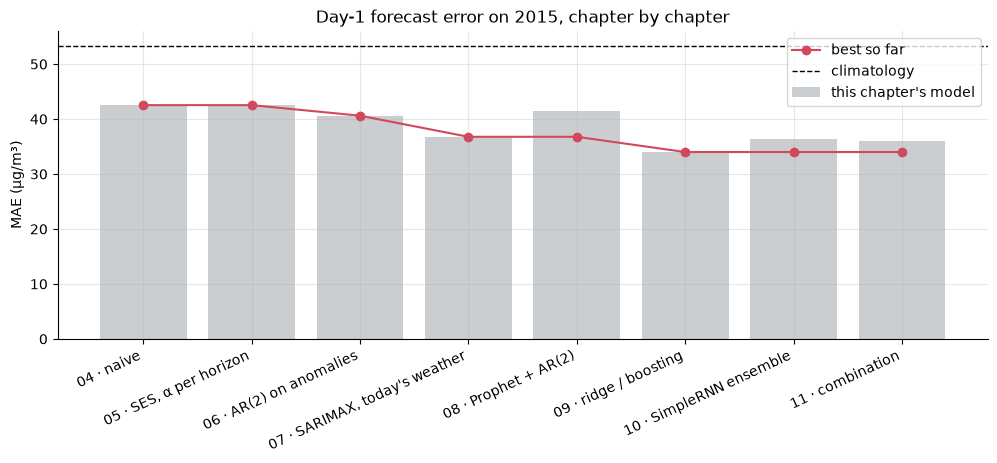

In [9]:
journey = pd.Series({
    "04 · naive": test_mae.loc["naive", 1],
    "05 · SES, α per horizon": test_mae.loc["SES (log), α per horizon", 1],
    "06 · AR(2) on anomalies": test_mae.loc["AR(2) on anomalies", 1],
    "07 · SARIMAX, today's weather": test_mae.loc["SARIMAX, today's weather", 1],
    "08 · Prophet + AR(2)": test_mae.loc["Prophet + AR(2) on residuals", 1],
    "09 · ridge / boosting": test_mae.loc[["Ridge, direct", "Gradient boosting, direct"], 1].min(),
    "10 · SimpleRNN ensemble": test_mae.loc["SimpleRNN, 5-seed ensemble", 1],
    "11 · combination": test_mae.loc["Combination (ridge + SARIMAX + AR(2))", 1],
})
best_so_far = journey.cummin()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(journey)), journey, color=tsutils.PALETTE[4], alpha=0.35, label="this chapter's model")
ax.plot(range(len(journey)), best_so_far, marker="o", color=tsutils.PALETTE[1], label="best so far")
ax.axhline(test_mae.loc["climatology (median)", 1], color="k", ls="--", lw=1, label="climatology")
ax.set_xticks(range(len(journey)), journey.index, rotation=25, ha="right")
ax.set(title="Day-1 forecast error on 2015, chapter by chapter", ylabel="MAE (µg/m³)")
ax.legend()
print(f"from naive to the best honest model: {1 - best_so_far.iloc[-1] / journey.iloc[0]:.0%} lower error")

### The forecasts against reality

December 2015 was an extraordinary month in Beijing: the city issued its first-ever **red alerts** for air pollution. Here is the lead model's day-1 forecast through the last quarter of 2015, with the naive forecast for comparison.

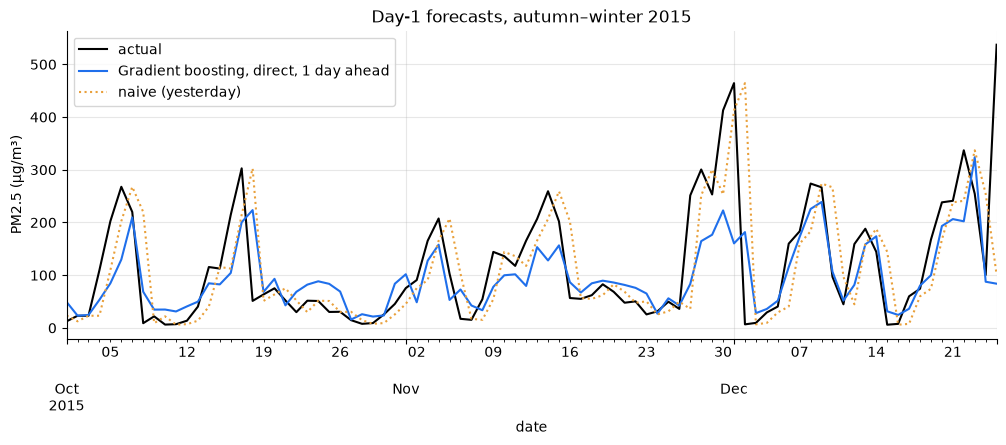

In [10]:
LEAD = "Gradient boosting, direct"          # fixed in section 1 from its 2014 score
day1 = test_runs[LEAD].query("h == 1").set_index("date")
naive1 = test_runs["naive"].query("h == 1").set_index("date")

window = slice("2015-10-01", "2015-12-31")
ax = day1.loc[window, "actual"].plot(color="k", lw=1.5, label="actual")
day1.loc[window, "forecast"].plot(ax=ax, color=tsutils.PALETTE[0], label=f"{LEAD}, 1 day ahead")
naive1.loc[window, "forecast"].plot(ax=ax, color=tsutils.PALETTE[3], ls=":", label="naive (yesterday)")
ax.set(title="Day-1 forecasts, autumn–winter 2015", ylabel="PM2.5 (µg/m³)")
ax.legend(loc="upper left");

Two things stand out:

- **Naive is always a day late.** It's the actual series shifted by one day, so it forecasts smog on the day the smog clears.
- **The model often catches clean-ups on the day they happen.** On 1 December, after a day near 460 µg/m³, it forecast about 180, where naive said 460, and the air did in fact clear. The evening wind announces those clean-ups (chapter 07). What the model can't do is see **build-ups** coming. Peaks such as the end of November are under-forecast, because an episode starts with stagnant air settling in gradually, and the model's median-type forecasts are cautious on the high side.

### A smog-alert forecast

Users rarely need the exact number. They need to know **"will tomorrow be a heavy-pollution day?"** We use 150 µg/m³, the daily PM2.5 level at which China's air-quality index enters its *heavily polluted* band.

The alert rule is **"warn if tomorrow's forecast is at least $c$"**. Median-type forecasts run low on the worst days, so the best $c$ can sit below 150. We choose $c$ on **2014** to maximise the *critical success index*, $\text{CSI} = \frac{\text{hits}}{\text{hits} + \text{misses} + \text{false alarms}}$, a standard score for rare-event forecasts that ignores the easy "correct no-alert" days. Then we apply it unchanged to 2015. The comparison is the **persistence** rule: "warn if today was a heavy-pollution day".

In [11]:
HEAVY = 150        # µg/m³, daily mean

def alert_scores(warn_signal, observed, level):
    """Hits, misses and false alarms for 'warn when warn_signal >= level' against heavy days."""
    warn, event = warn_signal >= level, observed >= HEAVY
    hits, misses, false_alarms = (warn & event).sum(), (~warn & event).sum(), (warn & ~event).sum()
    return {"heavy days": int(event.sum()), "alerts issued": int(warn.sum()),
            "hit rate": hits / max(event.sum(), 1), "false-alarm share": false_alarms / max(warn.sum(), 1),
            "CSI": hits / max(hits + misses + false_alarms, 1)}

def day1(bt):
    frame = bt.query("h == 1").dropna(subset=["actual"])
    return frame, frame["forecast"].to_numpy(), frame["actual"].to_numpy()

# choose the alert level on 2014, using the lead model's 2014 forecasts (same recipe)
_, f14, a14 = day1(tsutils.backtest(y, from_table(direct_ml(boosting, DEV)), DEV, H, actuals=actual))
csi_2014 = {level: alert_scores(f14, a14, level)["CSI"] for level in range(80, 205, 5)}
alert_level = max(csi_2014, key=csi_2014.get)
print(f"alert level chosen on 2014: forecast ≥ {alert_level} µg/m³ (CSI {csi_2014[alert_level]:.2f} on 2014)")

# apply it, unchanged, to 2015
frame15, f15, a15 = day1(test_runs[LEAD])
today15 = y.reindex(frame15["origin"]).to_numpy()
pd.DataFrame({f"{LEAD}: warn if forecast ≥ {alert_level}": alert_scores(f15, a15, alert_level),
              "persistence: warn if today ≥ 150": alert_scores(today15, a15, HEAVY)}).T.style.format(
    {"heavy days": "{:.0f}", "alerts issued": "{:.0f}", "hit rate": "{:.0%}", "false-alarm share": "{:.0%}", "CSI": "{:.2f}"})

alert level chosen on 2014: forecast ≥ 110 µg/m³ (CSI 0.48 on 2014)


,heavy days,alerts issued,hit rate,false-alarm share,CSI
"Gradient boosting, direct: warn if forecast ≥ 110",51,59,65%,44%,0.43
persistence: warn if today ≥ 150,51,50,53%,46%,0.36


The alert level chosen on 2014 is **below** 150 µg/m³. Median-type forecasts run low on the worst days, so the model has to be asked to warn a little earlier. Applied unchanged to 2015:

- The lead model **flagged about two out of three heavy-pollution days the evening before** (hit rate 65%). About 44% of its alerts turned out to be false alarms.
- Persistence, "warn if today was heavy", caught about half (53%), with a similar false-alarm share, and by construction it can never warn about the *first* day of an episode.
- The CSI, 0.43 against 0.36, summarises the gain.

For a user, this is the most concrete result in the course: a warning system built only from local measurements, honestly tested on a year it never saw, that catches most heavy-pollution days a day in advance. The misses are typically the onsets of new episodes, the build-ups the plot above showed the model is slow to see. Reducing them would take a weather forecast.

---
## 6. The same methods on a predictable series

It's worth ending the results with a reminder of where the difficulty comes from. Here's the same city and the same file, but a different column: **daily mean temperature**, forecast 1–7 days ahead over 2015 with the same backtest. Temperature follows the calendar closely (chapter 02 found a seasonal strength of 0.96).

In [12]:
temperature = tsutils.load_beijing()["temp"].resample("D").mean().interpolate()

def temp_climatology(history, horizon):
    return tsutils.climatology_forecast(history, horizon, window=15, stat="mean")

def temp_ridge(origins):
    forecasts = {}
    for h in range(1, H + 1):
        X = pd.DataFrame(index=temperature.index)
        for k in [0, 1, 2, 6]:
            X[f"lag_{k}"] = temperature.shift(k)
        X["mean_7"] = temperature.rolling(7).mean()
        for column in ["dew_point", "humidity", "pressure", "pressure_change", "nw_share", "wind"]:
            X[column] = weather[column]
        target_doy = (X.index + pd.Timedelta(days=h)).dayofyear.to_numpy()
        X["sin"], X["cos"] = np.sin(2 * np.pi * target_doy / 365.25), np.cos(2 * np.pi * target_doy / 365.25)
        target = temperature.shift(-h)
        complete = X.notna().all(axis=1) & target.notna()
        for _, month_origins in pd.Series(origins, index=origins).groupby([origins.year, origins.month]):
            usable = complete & (X.index <= month_origins.iloc[0] - pd.Timedelta(days=h))
            model = ridge().fit(X[usable], target[usable])
            forecasts.update({(o, h): p for o, p in zip(month_origins, model.predict(X.loc[month_origins.to_numpy()]))})
    return forecasts

temp_scores = pd.DataFrame({
    name: tsutils.evaluate(tsutils.backtest(temperature, f, TEST, H))["MAE"]
    for name, f in [("naive", tsutils.naive_forecast), ("climatology", temp_climatology),
                    ("ridge (lags, today's weather, season)", from_table(temp_ridge(TEST)))]
}).T
temp_scores.round(2)

h,1,2,3,4,5,6,7
naive,1.6,2.3,2.6,2.7,2.7,2.8,3.1
climatology,2.3,2.3,2.3,2.3,2.3,2.3,2.3
"ridge (lags, today's weather, season)",1.4,2.0,2.1,2.1,2.2,2.2,2.3


Temperature tells the same story in a friendlier range of numbers. Ridge's day-1 error is about **1.4 °C**, for a series whose daily means ran from about −7 to +32 °C over the year. Naive is close behind, and by days 6–7 ridge converges to **climatology (≈ 2.3 °C)**. It's the same shape as PM2.5: skill for a few days, then back to "typical for the season".

The difference isn't the methods. It's where each series' structure lives. **Temperature's structure lives in the calendar**: its climatology alone is already excellent (chapter 02 measured a seasonal strength of 0.96). **PM2.5's structure lives in the weather**: its climatology is poor (about 54 µg/m³ of error in a year averaging about 83), and the weather that drives it can only be seen a day ahead. The same toolkit gives impressive-looking numbers on the first kind of series, and honest, modest, still useful numbers on the second.

---
## 7. What the course has shown

**About forecasting PM2.5**

- Beijing's PM2.5 is **mean-reverting with a half-life of about a day** (chapter 03). Tomorrow is forecastable; next week, beyond the season, largely isn't.
- The skill for tomorrow comes from **recent memory** (chapters 06, 09) and **today's weather**, especially the evening wind (chapters 07, 09).
- The ceiling is set by information, not algorithms: with **perfect weather forecasts** the errors would fall sharply (chapter 07). Operational air-quality services get their skill from weather and chemistry models, which no single dataset contains.

**About forecasting in general**

- **Baselines first.** Naive and climatology were hard to beat, and each model's worth is measured against them (chapter 04).
- **Honest evaluation** means a rolling origin, no leakage, tuning on one period and reporting on another, and a **locked test set** opened once, as here.
- **Match the model to the data's behaviour.** Exponential smoothing and Prophet assume persistence and a smooth calendar curve. They excelled on CO₂ and struggled on a series that snaps back (chapters 05, 08).
- **Better inputs usually beat bigger models** on small data (chapters 09–10). Deep learning earned its place where there was more data and richer dynamics (chapter 10, hourly).
- **Check uncertainty**, not just point forecasts. Intervals must be checked against outcomes (chapters 04–08).
- **Report variability.** Random seeds, noisy test windows and small samples all move the numbers (chapter 10).
- **Lock a test set and open it once.** Here the 2014 rankings largely held on 2015, the pre-declared combination didn't win, and the biases surprised us. All three are findings you only get from a test you can't tune on.

---
## Exercises

### Exercise 1: Would a different combination have been better?
Compute the 2015 MAE of every equal-weight average of **two or three** of the finalists (excluding the baselines), and find the best. Then ask: would you have picked it using **2014** alone? Use the 2014 forecasts, which you can rebuild with `run_all(DEV, ...)`, to rank the same combinations.

<details><summary>Solution</summary>

```python
from itertools import combinations

candidates = [n for n in test_runs if n not in ("naive", "climatology (median)") and not n.startswith("Combination")]
dev_runs = run_all(DEV, tuning_origins=pd.date_range("2012-12-31", "2013-12-24", freq="D"))

def combo_mae(runs, names):
    frame = runs[names[0]].copy()
    frame["forecast"] = np.mean([runs[n]["forecast"].to_numpy() for n in names], axis=0)
    return tsutils.evaluate(frame)["MAE"].mean()

rows = []
for k in (2, 3):
    for names in combinations(candidates, k):
        rows.append({"members": " + ".join(names), "2014 mean MAE": combo_mae(dev_runs, list(names)),
                     "2015 mean MAE": combo_mae(test_runs, list(names))})
table = pd.DataFrame(rows)
table["rank 2014"], table["rank 2015"] = table["2014 mean MAE"].rank(), table["2015 mean MAE"].rank()
table.sort_values("2015 mean MAE").head(8).round(1)
```
The best 2015 combination is only slightly better than the one declared in advance, and on 2014 it ranked far down the list. **None of them beats ridge on its own.** Picking the winner *after* seeing the test results would report an optimistic number. Declaring the combination beforehand, as section 1 did, gives up a little accuracy in exchange for a score you can trust.
</details>

### Exercise 2: How do errors depend on the pollution level?
For the lead model's day-1 forecasts in 2015, group the absolute errors by the **actual** PM2.5 band (0–35, 35–75, 75–150, 150–250, 250+ µg/m³). Report the count, the median absolute error and the median *relative* error in each band. Where does most of the total error come from?

<details><summary>Solution</summary>

```python
frame = test_runs[LEAD].query("h == 1").dropna(subset=["actual"]).copy()
frame["abs_error"] = (frame["forecast"] - frame["actual"]).abs()
frame["relative_error"] = frame["abs_error"] / frame["actual"]
frame["band"] = pd.cut(frame["actual"], [0, 35, 75, 150, 250, np.inf], labels=["0–35", "35–75", "75–150", "150–250", "250+"])
summary = frame.groupby("band", observed=True).agg(days=("abs_error", "size"), median_abs_error=("abs_error", "median"),
                                                   median_relative_error=("relative_error", "median"),
                                                   share_of_total_error=("abs_error", "sum"))
summary["share_of_total_error"] /= frame["abs_error"].sum()
summary["share_of_days"] = summary["days"] / summary["days"].sum()
summary.style.format({"median_abs_error": "{:.0f}", "median_relative_error": "{:.0%}",
                      "share_of_total_error": "{:.0%}", "share_of_days": "{:.0%}"})
```
Absolute errors grow steeply with the pollution level. The heavy days (150 µg/m³ and above) are only about one day in seven, but they account for over a third of the total error, and the worst few days (250+) alone contribute nearly a fifth. That's why the MAE looks large: it's driven by the hardest days. Relative errors tell a more even story, and they're largest on the cleanest days, where small absolute misses are large percentages (chapter 04's argument against MAPE).
</details>

---
## Where to go next

- **Probabilistic forecasting:** forecast whole distributions (quantile regression, conformal prediction) and score them with proper scoring rules such as the CRPS.
- **Many series at once:** global models trained across stations or cities, and hierarchical forecasting that keeps city and district forecasts consistent.
- **External forecasts as inputs:** numerical weather prediction, the ingredient our oracle showed is worth the most.
- **Further reading:** Hyndman & Athanasopoulos, *Forecasting: Principles and Practice* (free online), covers most of this course's statistical methods in depth.

Thank you for working through the course.